In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler , PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor  , GradientBoostingRegressor
from sklearn.metrics import (
        accuracy_score,
        mean_absolute_error,mean_squared_error,r2_score
    )
from sklearn.model_selection import train_test_split ,cross_val_score , learning_curve,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv('D:\Fci 2025-2026\Software Development\Elxair_Project\Elxair\Model\perfume_sales_dataset.csv')
df.head()

,OrderId,ProductID,Name,Month,BottleSize,Category,Gender,Season,SoldInSeason,DiscountPercent,CostPerBottle,SellingPrice,QuantitySold
0,1,24,Ultra Male,May,50ml,Oriental,Him,Winter,0,20.0,200,450,3
1,2,21,Musk Pink,February,30ml,Fruity,Her,Summer,0,30.0,150,300,4
2,3,1,Le Male Elixir,July,5ml,Oriental,Him,Winter,0,10.0,20,50,3
3,4,6,Oud,July,20ml,Musk,Unisex,Winter,0,10.0,45,200,2
4,5,20,Musk Roman,July,5ml,Musk,Unisex,All Seasons,1,30.0,20,50,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderId          50000 non-null  int64  
 1   ProductID        50000 non-null  int64  
 2   Name             50000 non-null  object 
 3   Month            50000 non-null  object 
 4   BottleSize       50000 non-null  object 
 5   Category         50000 non-null  object 
 6   Gender           50000 non-null  object 
 7   Season           50000 non-null  object 
 8   SoldInSeason     50000 non-null  int64  
 9   DiscountPercent  50000 non-null  float64
 10  CostPerBottle    50000 non-null  int64  
 11  SellingPrice     50000 non-null  int64  
 12  QuantitySold     50000 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 5.0+ MB


In [4]:
df.describe(include='all')

,OrderId,ProductID,Name,Month,BottleSize,Category,Gender,Season,SoldInSeason,DiscountPercent,CostPerBottle,SellingPrice,QuantitySold
count,50000.000000,50000.000000,50000,50000,50000,50000,50000,50000,50000.000000,50000.0000,50000.000000,50000.000000,50000.000000
unique,NaN,NaN,24,12,6,6,3,3,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Black Opium,September,20ml,Oriental,Him,Summer,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2158,4277,8401,16843,29127,18606,NaN,NaN,NaN,NaN,NaN
mean,25000.500000,12.486260,NaN,NaN,NaN,NaN,NaN,NaN,0.585660,35.0922,132.950100,284.291000,3.991060
std,14433.901067,6.932767,NaN,NaN,NaN,NaN,NaN,NaN,0.492613,17.5905,117.708269,192.890439,3.356076
min,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,10.0000,20.000000,50.000000,0.000000
25%,12500.750000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,20.0000,30.000000,100.000000,2.000000
50%,25000.500000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,30.0000,150.000000,300.000000,3.000000
75%,37500.250000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,50.0000,200.000000,450.000000,6.000000


In [5]:
outlires_cols = [ 'DiscountPercent' , 'CostPerBottle' , 'SellingPrice' , 'QuantitySold']

def remove_outliers(df , columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df
    
df = remove_outliers(df , outlires_cols)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 48403 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderId          48403 non-null  int64  
 1   ProductID        48403 non-null  int64  
 2   Name             48403 non-null  object 
 3   Month            48403 non-null  object 
 4   BottleSize       48403 non-null  object 
 5   Category         48403 non-null  object 
 6   Gender           48403 non-null  object 
 7   Season           48403 non-null  object 
 8   SoldInSeason     48403 non-null  int64  
 9   DiscountPercent  48403 non-null  float64
 10  CostPerBottle    48403 non-null  int64  
 11  SellingPrice     48403 non-null  int64  
 12  QuantitySold     48403 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 5.2+ MB


In [6]:
df.isnull().sum()

OrderId            0
ProductID          0
Name               0
Month              0
BottleSize         0
Category           0
Gender             0
Season             0
SoldInSeason       0
DiscountPercent    0
CostPerBottle      0
SellingPrice       0
QuantitySold       0
dtype: int64

In [7]:
df.head()

,OrderId,ProductID,Name,Month,BottleSize,Category,Gender,Season,SoldInSeason,DiscountPercent,CostPerBottle,SellingPrice,QuantitySold
0,1,24,Ultra Male,May,50ml,Oriental,Him,Winter,0,20.0,200,450,3
1,2,21,Musk Pink,February,30ml,Fruity,Her,Summer,0,30.0,150,300,4
2,3,1,Le Male Elixir,July,5ml,Oriental,Him,Winter,0,10.0,20,50,3
3,4,6,Oud,July,20ml,Musk,Unisex,Winter,0,10.0,45,200,2
4,5,20,Musk Roman,July,5ml,Musk,Unisex,All Seasons,1,30.0,20,50,10


In [8]:
df["ProfitMargin"] = (df["SellingPrice"] - df["CostPerBottle"]) / df["SellingPrice"]

df["BottleVolume"] = (
    df["BottleSize"]
    .str.replace("ml", "", regex=False)
    .astype(int)
)

def price_category(price):
    if price <= 150:
        return "Cheap"
    elif price <= 400:
        return "Mid-Range"
    else:
        return "Premium"

df["PriceCategory"] = df["SellingPrice"].apply(price_category)


df.head()

,OrderId,ProductID,Name,Month,BottleSize,Category,Gender,Season,SoldInSeason,DiscountPercent,CostPerBottle,SellingPrice,QuantitySold,ProfitMargin,BottleVolume,PriceCategory
0,1,24,Ultra Male,May,50ml,Oriental,Him,Winter,0,20.0,200,450,3,0.555556,50,Premium
1,2,21,Musk Pink,February,30ml,Fruity,Her,Summer,0,30.0,150,300,4,0.500000,30,Mid-Range
2,3,1,Le Male Elixir,July,5ml,Oriental,Him,Winter,0,10.0,20,50,3,0.600000,5,Cheap
3,4,6,Oud,July,20ml,Musk,Unisex,Winter,0,10.0,45,200,2,0.775000,20,Mid-Range
4,5,20,Musk Roman,July,5ml,Musk,Unisex,All Seasons,1,30.0,20,50,10,0.600000,5,Cheap


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
monthly_df = (
    df.groupby(
        [
            'Month',
            'ProductID',
            'BottleSize',
            'BottleVolume'
        ]
    )
    .agg(
        Category = ("Category" , "first"),
        Gender = ("Gender" , "first"),
        Season = ("Season" , "first"),
        SoldInSeason = ("SoldInSeason" , "first"),
        PriceCategory = ("PriceCategory" , "first"),

        NumberOfTransactions=("OrderId", "nunique"),
        AvgDiscount = ("DiscountPercent" , "mean"),
        AvgMarginProfit = ("ProfitMargin" , "mean"),
        TotalQuantitySold = ("QuantitySold" , "sum")

    )
    .reset_index()
)
monthly_df.head()

,Month,ProductID,BottleSize,BottleVolume,Category,Gender,Season,SoldInSeason,PriceCategory,NumberOfTransactions,AvgDiscount,AvgMarginProfit,TotalQuantitySold
0,April,1,100ml,100,Oriental,Him,Winter,0,Premium,39,60.0,0.416667,80
1,April,1,10ml,10,Oriental,Him,Winter,0,Cheap,29,50.0,0.700000,76
2,April,1,20ml,20,Oriental,Him,Winter,0,Mid-Range,20,50.0,0.775000,48
3,April,1,30ml,30,Oriental,Him,Winter,0,Mid-Range,29,30.0,0.500000,47
4,April,1,50ml,50,Oriental,Him,Winter,0,Premium,32,30.0,0.555556,70


In [12]:
# Features
x = monthly_df.drop(
    columns=[
        "ProductID",
        "TotalQuantitySold"
    ]
)

# Target
y = monthly_df["TotalQuantitySold"]

# Train Test Split
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

# Columns
cat_cols = [
    "Month",
    "BottleSize",
    "Category",
    "Gender",
    "Season",
    "PriceCategory"
]

num_cols = [ 
    "BottleVolume", 
    "NumberOfTransactions",
    "AvgDiscount",
    "AvgMarginProfit"
]
# Preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat" , 
            OneHotEncoder(handle_unknown = "ignore" ),
            cat_cols
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ],
    remainder="passthrough"
)

#Pipeline
pipeline = Pipeline(
    steps = [
        ("preprocessor" , preprocessor),
        ("model" , RandomForestRegressor(
                n_estimators=300,
                max_depth=8,
                max_features=1.0,
                min_samples_split=10,
                min_samples_leaf=5,
                bootstrap=True,
                random_state=42,
                n_jobs=-1
        ))
    ]
)

# Train The Model
pipeline.fit(x_train , y_train)

# Prediction
y_pred = pipeline.predict(x_test)

print("Train R² :", pipeline.score(x_train, y_train))
print("Test R²  :", pipeline.score(x_test, y_test))

print("MAE :", mean_absolute_error(y_test, y_pred))



Train R² : 0.8907682424631042
Test R²  : 0.8289740554525038
MAE : 11.041966957284838


In [13]:
pred_train = pipeline.predict(x_train)
pred_test = pipeline.predict(x_test)

print("Train R2 :", r2_score(y_train,pred_train))
print("Test R2 :", r2_score(y_test,pred_test))

print("Train MAE :",mean_absolute_error(y_train,pred_train))
print("Test MAE :",mean_absolute_error(y_test,pred_test))


Train R2 : 0.8907682424631042
Test R2 : 0.8289740554525038
Train MAE : 9.351714175564878
Test MAE : 11.041966957284838


In [14]:
scores = cross_val_score(
    pipeline,
    x,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.81422313 0.83617043 0.82002329 0.85064362 0.84455162]
0.8331224192913235
0.013969110464102673


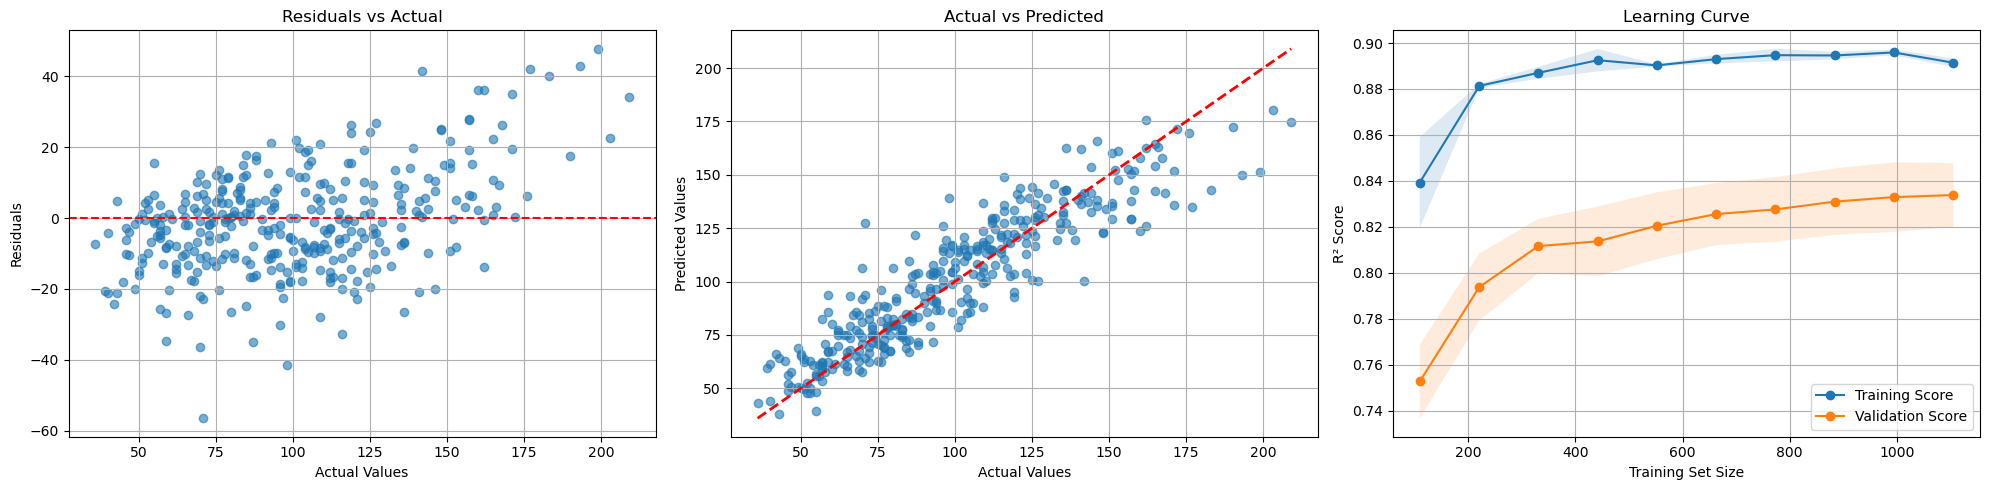

In [15]:
# Predictions & Residuals
y_pred = pipeline.predict(x_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ==========================================
# 1. Residuals vs Actual
# ==========================================
axes[0].scatter(y_test, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residuals vs Actual")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Residuals")
axes[0].grid(True)

# ==========================================
# 2. Actual vs Predicted
# ==========================================
axes[1].scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

axes[1].set_title("Actual vs Predicted")
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].grid(True)

# ==========================================
# 3. Learning Curve
# ==========================================
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=pipeline,
    X=x_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
valid_std = valid_scores.std(axis=1)

axes[2].plot(train_sizes, train_mean, marker='o', label='Training Score')
axes[2].plot(train_sizes, valid_mean, marker='o', label='Validation Score')

axes[2].fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

axes[2].fill_between(
    train_sizes,
    valid_mean - valid_std,
    valid_mean + valid_std,
    alpha=0.15
)

axes[2].set_title("Learning Curve")
axes[2].set_xlabel("Training Set Size")
axes[2].set_ylabel("R² Score")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [16]:
"""param_grid = {
    "model__n_estimators": [200,300,400,500,700],
    "model__max_depth": [5,8,10,12,15,None],
    "model__min_samples_split": [2,5,10,15],
    "model__min_samples_leaf": [1,2,3,5],
    "model__max_features": ["sqrt","log2",0.5,0.7,1.0],
    "model__bootstrap": [True, False]
}
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid.fit(x_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV Score:", grid.best_score_)"""

'param_grid = {\n    "model__n_estimators": [200,300,400,500,700],\n    "model__max_depth": [5,8,10,12,15,None],\n    "model__min_samples_split": [2,5,10,15],\n    "model__min_samples_leaf": [1,2,3,5],\n    "model__max_features": ["sqrt","log2",0.5,0.7,1.0],\n    "model__bootstrap": [True, False]\n}\ngrid = GridSearchCV(\n    pipeline,\n    param_grid=param_grid,\n    cv=5,\n    scoring="r2",\n    n_jobs=-1,\n    verbose=2\n)\n\ngrid.fit(x_train, y_train)\n\nprint("Best Parameters:")\nprint(grid.best_params_)\n\nprint("Best CV Score:", grid.best_score_)'

In [17]:
"""best_pipeline = grid.best_estimator_

y_pred = best_pipeline.predict(x_test)

print("Train R² :", best_pipeline.score(x_train, y_train))
print("Test R²  :", best_pipeline.score(x_test, y_test))

print("MAE :", mean_absolute_error(y_test, y_pred))"""

'best_pipeline = grid.best_estimator_\n\ny_pred = best_pipeline.predict(x_test)\n\nprint("Train R² :", best_pipeline.score(x_train, y_train))\nprint("Test R²  :", best_pipeline.score(x_test, y_test))\n\nprint("MAE :", mean_absolute_error(y_test, y_pred))'

In [18]:
import joblib
joblib.dump(pipeline, "Random_Forest_Pipeline.pkl")

['Random_Forest_Pipeline.pkl']

In [19]:
monthly_df.shape

(1728, 13)

In [20]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(20))

                         Feature  Importance
37       remainder__SoldInSeason    0.436595
34     num__NumberOfTransactions    0.315076
33             num__BottleVolume    0.091834
30      cat__PriceCategory_Cheap    0.047264
36          num__AvgMarginProfit    0.039901
35              num__AvgDiscount    0.020950
32    cat__PriceCategory_Premium    0.008921
31  cat__PriceCategory_Mid-Range    0.004951
17           cat__BottleSize_5ml    0.003591
25               cat__Gender_Him    0.003148
14          cat__BottleSize_20ml    0.003109
22        cat__Category_Oriental    0.002814
27       cat__Season_All Seasons    0.002425
26            cat__Gender_Unisex    0.002355
13          cat__BottleSize_10ml    0.002147
24               cat__Gender_Her    0.001891
28            cat__Season_Summer    0.001814
29            cat__Season_Winter    0.001594
15          cat__BottleSize_30ml    0.001333
19          cat__Category_Fruity    0.001274


In [21]:
print(x.columns)

Index(['Month', 'BottleSize', 'BottleVolume', 'Category', 'Gender', 'Season',
       'SoldInSeason', 'PriceCategory', 'NumberOfTransactions', 'AvgDiscount',
       'AvgMarginProfit'],
      dtype='object')


In [22]:
print(x.columns.tolist())

['Month', 'BottleSize', 'BottleVolume', 'Category', 'Gender', 'Season', 'SoldInSeason', 'PriceCategory', 'NumberOfTransactions', 'AvgDiscount', 'AvgMarginProfit']


In [23]:
monthly_df.groupby("BottleSize")["TotalQuantitySold"].mean()

BottleSize
100ml     85.472222
10ml     115.791667
20ml     105.468750
30ml      95.944444
50ml      90.454861
5ml      120.225694
Name: TotalQuantitySold, dtype: float64